In [1]:
import numpy as np
from lsst.afw.image import ExposureF
from lsst.geom import Point2D
from xlens.utils.image import resize_array

ModuleNotFoundError: No module named 'lsst.afw'

In [50]:
hdul = fits.open('/taiga/illinois/las/astro/xinliuxl/DC1_sim_blended/sim_mode0/exp-i-09993.fits')

In [51]:
hdul.info()

Filename: /taiga/illinois/las/astro/xinliuxl/DC1_sim_blended/sim_mode0/exp-i-09993.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   ()      
  1  IMAGE         1 ImageHDU        32   (1500, 1500)   float32   
  2  MASK          1 ImageHDU        43   (1500, 1500)   int32   
  3  VARIANCE      1 ImageHDU        32   (1500, 1500)   float32   
  4  ARCHIVE_INDEX    1 BinTableHDU     41   12R x 7C   [1J, 1J, 1J, 1J, 1J, 64A, 64A]   
  5  Detector      1 BinTableHDU    115   1R x 22C   [1QA(10), 1J, 1J, 1QA(7), 1J, 1J, 1J, 1J, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1J, 1QE(9), 1QA(3), 1J]   
  6  TransformMap    1 BinTableHDU     33   3R x 5C   [1QA(10), 1QA(10), 1QA(12), 1QA(10), 1J]   
  7  TransformPoint2ToPoint2    1 BinTableHDU     17   3R x 1C   [1QB(2484)]   
  8  Detector      2 BinTableHDU    201   3R x 38C   [3X, 1QA(5), 1J, 1J, 1J, 1J, 1D, 1D, 1D, 1D, 1J, 1QD(0), 1QA(1), 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1J, 1

In [49]:
hdul[1].data['gamma1']

array([-0.02, -0.02, -0.02, ..., -0.02, -0.02, -0.02],
      shape=(62522,), dtype='>f8')

In [1]:
plt.figure(figsize=(10, 10), dpi = 800)
plt.imshow(np.log(hdul[12].data['image']+0.01), origin='lower', cmap='gray')
plt.show()

NameError: name 'plt' is not defined

## Phase 1: Stitch Test — Load cutouts & stitch into large image

In [2]:
import sys
sys.path.insert(0, '/projects/bdsp/wenyinli/codes/single_galaxies')

import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import simple_norm
from src.anacal.detection_ml_pipeline import (
    load_and_stitch_one_batch,
    generate_grid_positions,
    stitch_large_image,
    match_detections_to_truth,
)

# ---- Parameters ----
DATA_DIR = "/work/nvme/bfmo/wenyinli/datasets/xlens_shift"
SHEAR_COMP = "g1"
SHEAR_MODE = 2          # mode 2 = no shear (training mode)
BATCH_INDEX = 0         # img_0/
NOISE_LEVEL = 0.594     # use 0 for noise-free test

# ---- Load & Stitch ----
large_image, positions, cutouts, cat, canvas_size, psf_image, noise_levels = load_and_stitch_one_batch(
    shear_comp=SHEAR_COMP,
    shear_mode=SHEAR_MODE,
    index=BATCH_INDEX,
    directory=DATA_DIR,
    noise_level=NOISE_LEVEL,
    noise_mode="fixed",
    nx=10, ny=10,
    sep=64,
    margin=50,
    stamp_size=64,
)

print(f"Canvas size: {canvas_size} x {canvas_size}")
print(f"Number of cutouts placed: {len(positions)}")
print(f"Large image shape: {large_image.shape}")
print(f"PSF image shape: {psf_image.shape}")
print(f"Noise levels (per-galaxy): {noise_levels.shape}, range=[{noise_levels.min():.3f}, {noise_levels.max():.3f}]")
print(f"Large image min/max: {large_image.min():.2f} / {large_image.max():.2f}")

Canvas size: 740 x 740
Number of cutouts placed: 100
Large image shape: (740, 740)
PSF image shape: (64, 64)
Noise levels (per-galaxy): (100,), range=[0.594, 0.594]
Large image min/max: -2.92 / 368.55


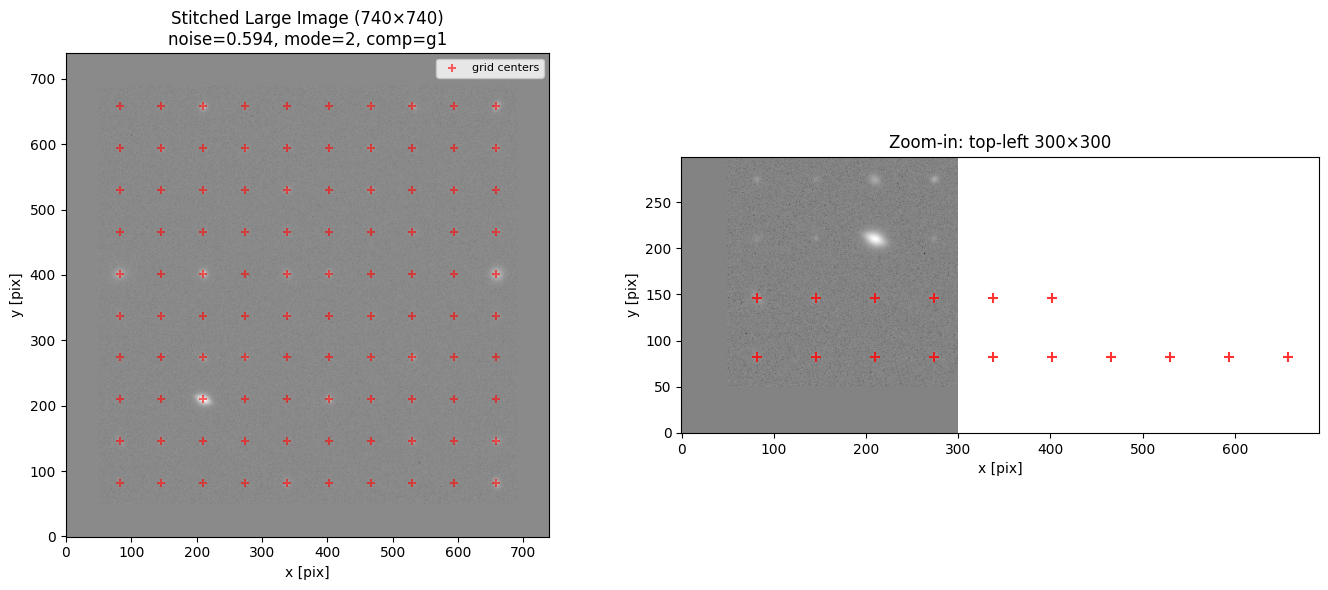

In [3]:
# ---- Visualize the stitched large image ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: full large image with log stretch
ax = axes[0]
im = ax.imshow(
    np.log(large_image - large_image.min() + 0.01),
    origin='lower', cmap='gray',
)
ax.set_title(f"Stitched Large Image ({canvas_size}×{canvas_size})\n"
             f"noise={NOISE_LEVEL}, mode={SHEAR_MODE}, comp={SHEAR_COMP}")
ax.set_xlabel("x [pix]")
ax.set_ylabel("y [pix]")

# Overlay grid positions as red dots
ax.scatter(positions[:, 1], positions[:, 0], 
           marker='+', color='red', s=30, alpha=0.6, label='grid centers')
ax.legend(fontsize=8)

# Right: zoom-in on first few galaxies (top-left corner)
ax = axes[1]
zoom = 300  # zoom region size
ax.imshow(
    np.log(large_image[:zoom, :zoom] - large_image[:zoom, :zoom].min() + 0.01),
    origin='lower', cmap='gray',
)
ax.set_title(f"Zoom-in: top-left {zoom}×{zoom}")
ax.scatter(positions[:16, 1], positions[:16, 0], 
           marker='+', color='red', s=50, alpha=0.8)
ax.set_xlabel("x [pix]")
ax.set_ylabel("y [pix]")

plt.tight_layout()
#plt.savefig("./plots/stitch_test.png", dpi=150, bbox_inches='tight')
plt.show()

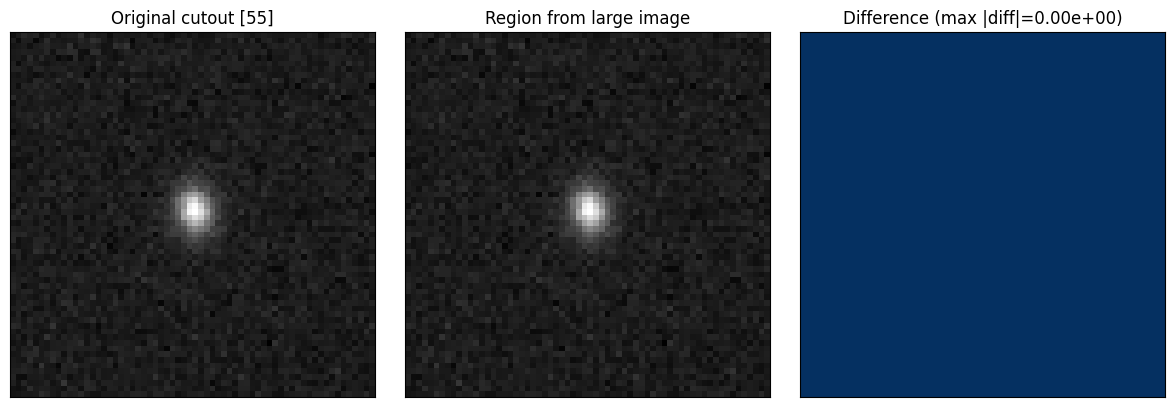

Max absolute pixel difference: 0.00e+00
Are they identical? True


In [4]:
# ---- Sanity check: compare individual cutout vs extracted region from large image ----
check_idx = 55  # pick a cutout index to verify

yc, xc = positions[check_idx]
half = 32

# Extract the same region from the large image
region_from_large = large_image[yc-half:yc+half, xc-half:xc+half]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ax = axes[0]
ax.imshow(cutouts[check_idx], origin='lower', cmap='gray')
ax.set_title(f"Original cutout [{check_idx}]")

ax = axes[1]
ax.imshow(region_from_large, origin='lower', cmap='gray')
ax.set_title(f"Region from large image")

ax = axes[2]
diff = cutouts[check_idx] - region_from_large
vmax = np.abs(diff).max()
ax.imshow(diff, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_title(f"Difference (max |diff|={vmax:.2e})")

for a in axes:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout()
plt.show()

# Also print the per-pixel max difference
print(f"Max absolute pixel difference: {np.abs(diff).max():.2e}")
print(f"Are they identical? {np.allclose(cutouts[check_idx], region_from_large)}")

### Optional: Noise-free test for cleaner visual inspection

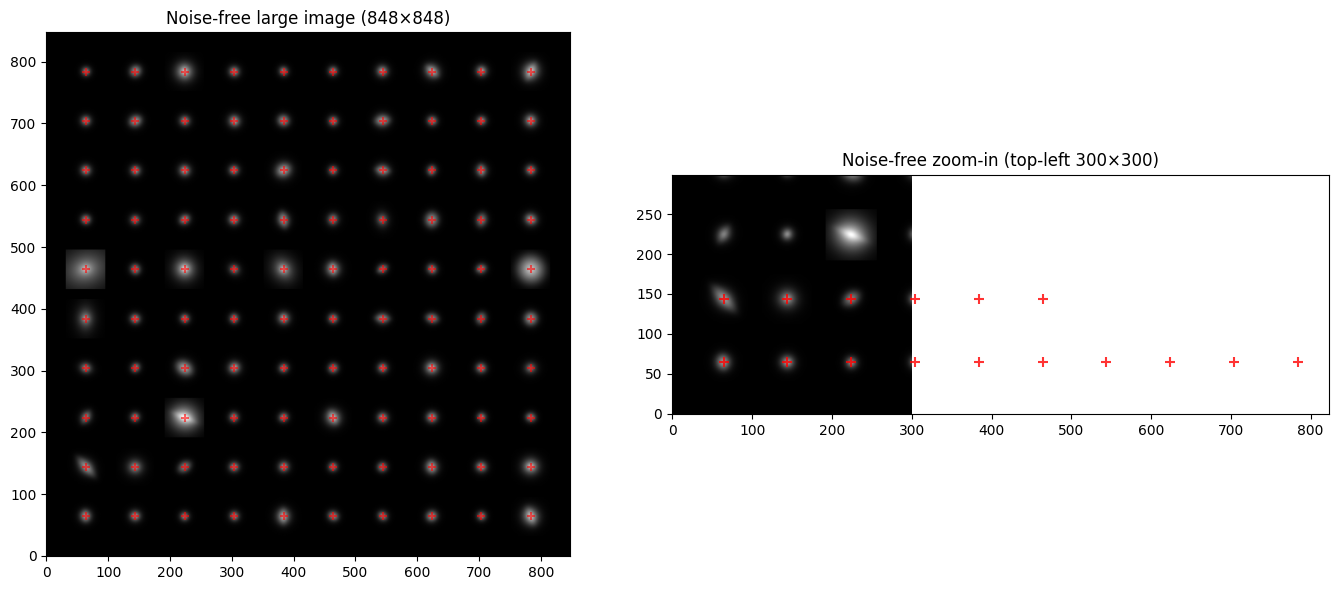

In [5]:
# ---- Load & stitch WITHOUT noise ----
large_nn, pos_nn, cuts_nn, cat_nn, cs_nn, psf_nn, noise_nn = load_and_stitch_one_batch(
    shear_comp=SHEAR_COMP,
    shear_mode=SHEAR_MODE,
    index=BATCH_INDEX,
    directory=DATA_DIR,
    noise_level=0.0,        # <-- NO noise
    nx=10, ny=10,
    sep=80, margin=32, stamp_size=64,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.imshow(np.log(large_nn - large_nn.min() + 0.01), origin='lower', cmap='gray')
ax.set_title(f"Noise-free large image ({cs_nn}×{cs_nn})")
ax.scatter(pos_nn[:, 1], pos_nn[:, 0], marker='+', color='red', s=30, alpha=0.6)

ax = axes[1]
ax.imshow(np.log(large_nn[:300, :300] - large_nn[:300, :300].min() + 0.01),
           origin='lower', cmap='gray')
ax.set_title("Noise-free zoom-in (top-left 300×300)")
ax.scatter(pos_nn[:16, 1], pos_nn[:16, 0], marker='+', color='red', s=50, alpha=0.8)

plt.tight_layout()
plt.show()

In [6]:
## Phase 2: FPFS Detection Test — Run anacal detection on the stitched large image

In [7]:
# ---- Phase 2: Setup FPFS config and import detection function ----
import anacal
from src.anacal.detection_ml_pipeline import run_fpfs_detection

# FPFS configuration (same as used in fpfs.py)
fpfs_config = anacal.fpfs.FpfsConfig(
    sigma_shapelets=0.52,    # detection scale
    sigma_shapelets1=0.45,   # measurement scale 1
    sigma_shapelets2=0.55,   # measurement scale 2
)

# Noise variance = sigma^2
noise_variance = NOISE_LEVEL**2 if NOISE_LEVEL > 0 else 1e-4

print(f"noise_variance = {noise_variance:.2e}")
print(f"FPFS config: sigma_as=0.52, sigma1=0.45, sigma2=0.55")

noise_variance = 3.53e-01
FPFS config: sigma_as=0.52, sigma1=0.45, sigma2=0.55


In [8]:
# ---- Run FPFS detection on the NOISY large image ----
# Re-run the stitch cell first if large_image is not in memory
print("Running FPFS detection on noisy large image...")
print(f"Image shape: {large_image.shape}, PSF shape: {psf_image.shape}")

det_cat = run_fpfs_detection(
    large_image=large_image,
    psf_image=psf_image,
    fpfs_config=fpfs_config,
    mag_zero=30.0,
    pixel_scale=0.2,
    noise_variance=noise_variance,
    noise_array=None,          # let anacal estimate internally
)

print(f"\nDetection complete!")
print(f"Number of detections: {len(det_cat)}")
print(f"Detection catalog dtype names: {det_cat.dtype.names}")

if len(det_cat) > 0:
    print(f"\nFirst 5 detections:")
    for name in det_cat.dtype.names:
        print(f"  {name}: {det_cat[name][:5]}")
else:
    print("WARNING: No objects detected! Check:")
    print("  - Is the image non-empty?")
    print("  - Is noise_variance set correctly?")
    print("  - Try the noise-free test below for debugging.")

Running FPFS detection on noisy large image...
Image shape: (740, 740), PSF shape: (64, 64)



Detection complete!
Number of detections: 98
Detection catalog dtype names: ('det_id', 'y', 'x', 'fpfs_e1', 'fpfs_e2', 'fpfs_R11', 'fpfs_R22', 'fpfs_w', 'fpfs_dw_dg1', 'fpfs_dw_dg2', 'fpfs_m00', 'fpfs_dm00_dg1', 'fpfs_dm00_dg2')

First 5 detections:
  det_id: [0 1 2 3 4]
  y: [ 82.  82. 146. 146.  82.]
  x: [ 82. 146.  82. 146. 210.]
  fpfs_e1: [-0.17873549  0.06672212 -0.05431865 -0.02116078  0.02697881]
  fpfs_e2: [-0.06807447  0.00117281 -0.36050923  0.00589054 -0.11870564]
  fpfs_R11: [0.33827853 0.08627323 0.64909957 0.65471835 0.28978051]
  fpfs_R22: [ 0.86348219  0.31437335  0.40803966 -0.12497645  0.20898882]
  fpfs_w: [1.         0.44097507 1.         1.         0.        ]
  fpfs_dw_dg1: [ 0.         47.40887387  0.          0.          0.        ]
  fpfs_dw_dg2: [ 0.         36.75617285  0.          0.          0.        ]
  fpfs_m00: [120.23614912 148.32080265 148.70593614 147.63631846  68.5328802 ]
  fpfs_dm00_dg1: [ 32.51537937 -14.78807028  12.06858969   4.66952084  -2.

In [9]:
# ---- Run FPFS detection on the NOISE-FREE large image ----
# This is a cleaner test: detection should be nearly perfect
if 'large_nn' in dir() and 'psf_nn' in dir():
    print("Running FPFS detection on noise-free large image...")
    
    det_cat_nn = run_fpfs_detection(
        large_image=large_nn,
        psf_image=psf_nn,
        fpfs_config=fpfs_config,
        mag_zero=30.0,
        pixel_scale=0.2,
        noise_variance=1e-4,    # small variance for noise-free
        noise_array=None,
    )
    
    print(f"Number of detections (noise-free): {len(det_cat_nn)}")
    if len(det_cat_nn) > 0:
        print(f"First 3 detection positions (y, x):")
        for i in range(min(3, len(det_cat_nn))):
            print(f"  [{i}] y={det_cat_nn['y'][i]:.1f}, x={det_cat_nn['x'][i]:.1f}")
else:
    print("Noise-free image not found in memory. Run the noise-free stitch cell first.")

Running FPFS detection on noise-free large image...


Number of detections (noise-free): 100
First 3 detection positions (y, x):
  [0] y=64.0, x=64.0
  [1] y=64.0, x=144.0
  [2] y=64.0, x=224.0


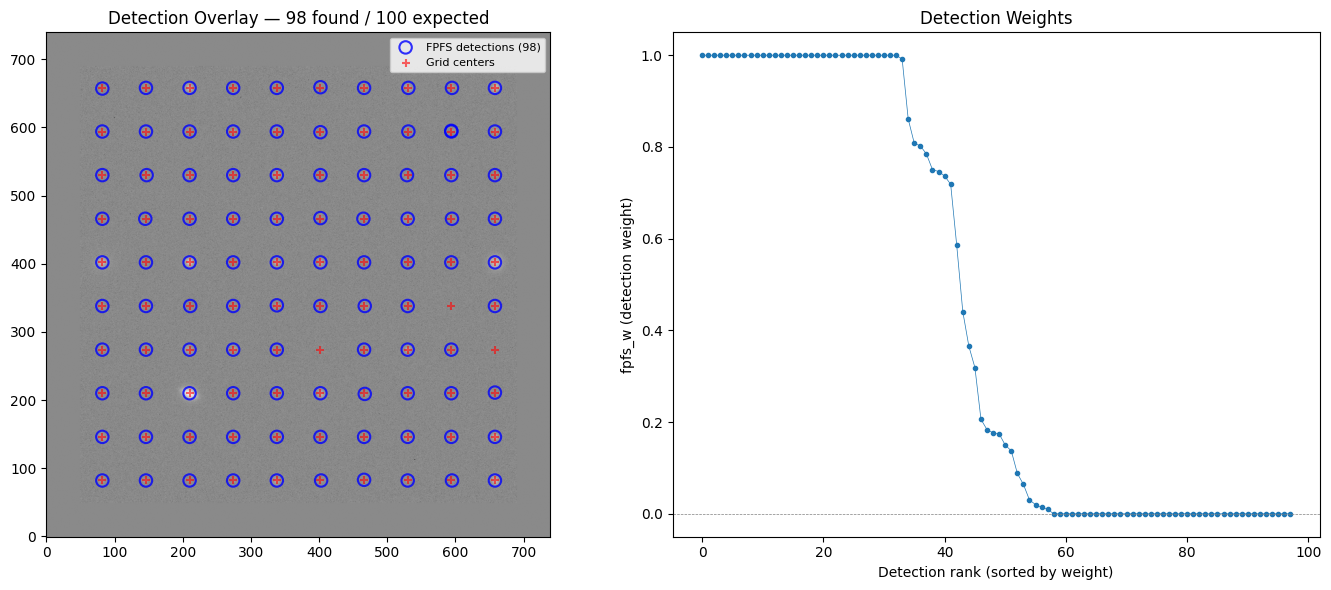

In [10]:
# ---- Visualize detection results overlaid on the large image ----
if len(det_cat) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: detection positions overlaid on log-stretched image
    ax = axes[0]
    ax.imshow(
        np.log(large_image - large_image.min() + 0.01),
        origin='lower', cmap='gray',
    )
    # Detections as blue circles
    ax.scatter(det_cat['x'], det_cat['y'], 
               marker='o', facecolors='none', edgecolors='blue', 
               s=80, linewidths=1.5, alpha=0.8, label=f'FPFS detections ({len(det_cat)})')
    # Grid centers as red +
    ax.scatter(positions[:, 1], positions[:, 0], 
               marker='+', color='red', s=30, alpha=0.6, label='Grid centers')
    ax.set_title(f"Detection Overlay — {len(det_cat)} found / {len(positions)} expected")
    ax.legend(fontsize=8)
    
    # Right: detection weight vs detection index (sorted)
    ax = axes[1]
    sorted_idx = np.argsort(det_cat['fpfs_w'])[::-1] if not np.all(np.isnan(det_cat['fpfs_w'])) else np.arange(len(det_cat))
    ax.plot(det_cat['fpfs_w'][sorted_idx], 'o-', markersize=3, linewidth=0.5)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Detection rank (sorted by weight)')
    ax.set_ylabel('fpfs_w (detection weight)')
    ax.set_title('Detection Weights')
    
    plt.tight_layout()
    plt.show()
else:
    print("No detections to visualize.")

### Debug: inspect raw anacal output columns

In [11]:
# ---- Debug: run detection again and inspect raw output ----
# This helps verify the actual column names from anacal.fpfs.process_image
import anacal

gal_array = large_image.astype(np.float64, copy=False)
psf_array = psf_image.astype(np.float64, copy=False)

raw_out = anacal.fpfs.process_image(
    fpfs_config=fpfs_config,
    mag_zero=30.0,
    gal_array=gal_array,
    psf_array=psf_array,
    pixel_scale=0.2,
    noise_variance=noise_variance,
    noise_array=None,
    detection=None,
    do_compute_detect_weight=True,
)

print(f"Type of raw output: {type(raw_out)}")
print(f"Length: {len(raw_out) if hasattr(raw_out, '__len__') else 'N/A'}")
if hasattr(raw_out, 'dtype'):
    print(f"Dtype: {raw_out.dtype}")
    if hasattr(raw_out.dtype, 'names') and raw_out.dtype.names is not None:
        print(f"Column names: {list(raw_out.dtype.names)}")
        print(f"\nFirst row:")
        for name in raw_out.dtype.names:
            print(f"  {name}: {raw_out[name][0]}")
    else:
        print(f"Raw data (first 200 chars): {str(raw_out)[:200]}")
else:
    print(f"Raw data (first 500 chars): {str(raw_out)[:500]}")

Type of raw output: <class 'numpy.ndarray'>
Length: 98
Dtype: [('y', '<f8'), ('x', '<f8'), ('fpfs_e1', '<f8'), ('fpfs_de1_dg1', '<f8'), ('fpfs_de1_dg2', '<f8'), ('fpfs_e2', '<f8'), ('fpfs_de2_dg1', '<f8'), ('fpfs_de2_dg2', '<f8'), ('fpfs_q1', '<f8'), ('fpfs_dq1_dg1', '<f8'), ('fpfs_dq1_dg2', '<f8'), ('fpfs_q2', '<f8'), ('fpfs_dq2_dg1', '<f8'), ('fpfs_dq2_dg2', '<f8'), ('fpfs_m00', '<f8'), ('fpfs_dm00_dg1', '<f8'), ('fpfs_dm00_dg2', '<f8'), ('fpfs_m20', '<f8'), ('fpfs_dm20_dg1', '<f8'), ('fpfs_dm20_dg2', '<f8'), ('fpfs_m22c', '<f8'), ('fpfs_dm22c_dg1', '<f8'), ('fpfs_dm22c_dg2', '<f8'), ('fpfs_m22s', '<f8'), ('fpfs_dm22s_dg1', '<f8'), ('fpfs_dm22s_dg2', '<f8'), ('fpfs_m42c', '<f8'), ('fpfs_dm42c_dg1', '<f8'), ('fpfs_dm42c_dg2', '<f8'), ('fpfs_m42s', '<f8'), ('fpfs_dm42s_dg1', '<f8'), ('fpfs_dm42s_dg2', '<f8'), ('fpfs_w', '<f8'), ('fpfs_dw_dg1', '<f8'), ('fpfs_dw_dg2', '<f8'), ('fpfs_m00_err', '<f8'), ('fpfs_flux', '<f8'), ('fpfs_dflux_dg1', '<f8'), ('fpfs_dflux_dg2', '<f8'), ('fpfs_flux

## Phase 3: Cut Stamps + ML Shape Measurement

In [12]:
# ---- Phase 3a: Load ML model + setup Calibrator ----
import torch
from src.anacal.batch_calibration import Calibrator
from src.architecture.forward8_CNN import Forward8_fixW_CNN
from src.anacal.detection_ml_pipeline import cut_stamps_from_large
from src.blending.ml_shape_measurement import ml_shape_measure, run_ml_on_detections

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the FPFS-trained model (same as shape_measurement.py)
MODEL_PATH = "./models/F8_fpfs_l5c32r01_50ep.pth"
model = Forward8_fixW_CNN(num_layers=5, base_channels=32, res_factor=0.1).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
print(f"Model loaded from {MODEL_PATH}")

# Setup calibrator (wraps model with response computation)
calibrator = Calibrator(model, device=device, dtype="float32")
print("Calibrator ready.")

Using device: cpu
Model loaded from ./models/F8_fpfs_l5c32r01_50ep.pth
Calibrator ready.


Cutting stamps for 100 detections (noise-free)...
Stamps shape: (100, 64, 64)
Offsets (dy, dx) range: [0.000, 0.000], [0.000, 0.000]


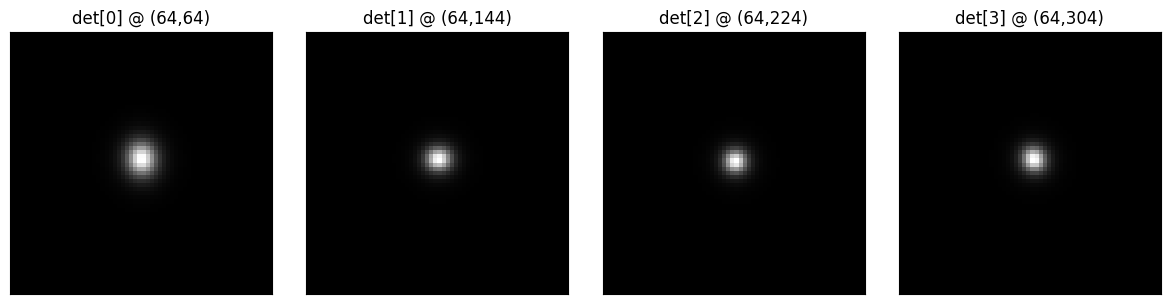

In [13]:
# ---- Phase 3b: Cut stamps from the NOISE-FREE large image ----
# Use noise-free data first for cleaner ML test
if 'det_cat_nn' in dir() and len(det_cat_nn) > 0:
    print(f"Cutting stamps for {len(det_cat_nn)} detections (noise-free)...")
    
    stamps_nn, offsets_nn = cut_stamps_from_large(
        large_image=large_nn,
        det_cat=det_cat_nn,
        stamp_size=64,
    )
    
    print(f"Stamps shape: {stamps_nn.shape}")
    print(f"Offsets (dy, dx) range: [{offsets_nn[:,0].min():.3f}, {offsets_nn[:,0].max():.3f}], "
          f"[{offsets_nn[:,1].min():.3f}, {offsets_nn[:,1].max():.3f}]")
    
    # Quick visual check: first 4 stamps
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for i in range(4):
        axes[i].imshow(stamps_nn[i], origin='lower', cmap='gray')
        axes[i].set_title(f"det[{i}] @ ({det_cat_nn['y'][i]:.0f},{det_cat_nn['x'][i]:.0f})")
        axes[i].set_xticks([]); axes[i].set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print("No noise-free detections available. Run Phase 2 noise-free cell first.")

In [14]:
# ---- Phase 3c: Run ML shape measurement on noise-free stamps ----
if 'stamps_nn' in dir() and len(stamps_nn) > 0:
    print(f"Running ML shape measurement on {len(stamps_nn)} stamps (noise-free)...")
    
    ml_shapes_nn, ml_R_nn = ml_shape_measure(
        stamps=stamps_nn,
        psf_image=psf_nn,
        calibrator=calibrator,
        pixel_scale=0.2,
        psf_fwhm=0.85,
        n_workers=8,          # use fewer workers in notebook
        dtype="float32",
    )
    
    print(f"ML shapes shape: {ml_shapes_nn.shape}")
    print(f"ML R shape: {ml_R_nn.shape}")
    
    # Print first 5 ML measurements
    print("\nFirst 5 ML measurements:")
    print(f"  e1: {ml_shapes_nn[:5, 0]}")
    print(f"  e2: {ml_shapes_nn[:5, 1]}")
    print(f"  R11: {ml_R_nn[:5, 0, 0, 0]}")
    print(f"  R22: {ml_R_nn[:5, 0, 1, 1]}")
    
    # Basic stats
    print(f"\nML e1: mean={ml_shapes_nn[:,0].mean():.4f}, std={ml_shapes_nn[:,0].std():.4f}")
    print(f"ML e2: mean={ml_shapes_nn[:,1].mean():.4f}, std={ml_shapes_nn[:,1].std():.4f}")
else:
    print("No stamps available. Run the cut-stamps cell first.")

Running ML shape measurement on 100 stamps (noise-free)...


prepare_q_images: 100%|██████████| 100/100 [00:00<00:00, 2883.24it/s]


ML shapes shape: (100, 2)
ML R shape: (100, 1, 2, 2)

First 5 ML measurements:
  e1: [-0.08851325  0.07558315 -0.01196219 -0.03667787 -0.19416317]
  e2: [-0.01877633 -0.00039636 -0.00070056 -0.0467447  -0.00206949]
  R11: [0.47026467 0.15858385 0.03101936 0.133534   0.47170165]
  R22: [0.49283478 0.18740846 0.03002202 0.12895137 0.5809616 ]

ML e1: mean=-0.0044, std=0.0811
ML e2: mean=-0.0116, std=0.0758


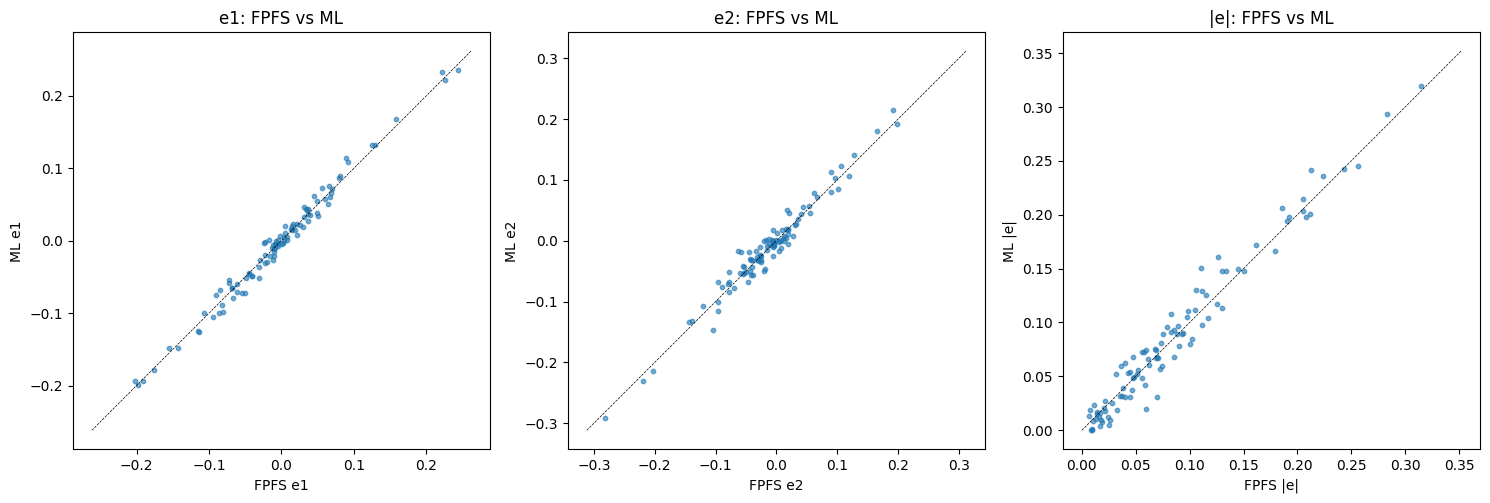

Pearson r (e1): 0.9927
Pearson r (e2): 0.9805


In [15]:
# ---- Phase 3d: Compare FPFS vs ML shapes (noise-free) ----
if 'ml_shapes_nn' in dir() and 'det_cat_nn' in dir():
    n_det = len(det_cat_nn)
    n_comp = min(n_det, len(ml_shapes_nn))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # e1 comparison
    ax = axes[0]
    ax.scatter(det_cat_nn['fpfs_e1'][:n_comp], ml_shapes_nn[:n_comp, 0], 
               alpha=0.6, s=10)
    lim = max(np.abs(ax.get_xlim()) + np.abs(ax.get_ylim())) / 2
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.5)
    ax.set_xlabel('FPFS e1')
    ax.set_ylabel('ML e1')
    ax.set_title('e1: FPFS vs ML')
    ax.set_aspect('equal')
    
    # e2 comparison
    ax = axes[1]
    ax.scatter(det_cat_nn['fpfs_e2'][:n_comp], ml_shapes_nn[:n_comp, 1], 
               alpha=0.6, s=10)
    lim = max(np.abs(ax.get_xlim()) + np.abs(ax.get_ylim())) / 2
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.5)
    ax.set_xlabel('FPFS e2')
    ax.set_ylabel('ML e2')
    ax.set_title('e2: FPFS vs ML')
    ax.set_aspect('equal')
    
    # |e| comparison
    ax = axes[2]
    e_fpfs = np.hypot(det_cat_nn['fpfs_e1'][:n_comp], det_cat_nn['fpfs_e2'][:n_comp])
    e_ml = np.hypot(ml_shapes_nn[:n_comp, 0], ml_shapes_nn[:n_comp, 1])
    ax.scatter(e_fpfs, e_ml, alpha=0.6, s=10)
    lim = max(e_fpfs.max(), e_ml.max()) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.5)
    ax.set_xlabel('FPFS |e|')
    ax.set_ylabel('ML |e|')
    ax.set_title('|e|: FPFS vs ML')
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation
    from scipy.stats import pearsonr
    r_e1, _ = pearsonr(det_cat_nn['fpfs_e1'][:n_comp], ml_shapes_nn[:n_comp, 0])
    r_e2, _ = pearsonr(det_cat_nn['fpfs_e2'][:n_comp], ml_shapes_nn[:n_comp, 1])
    print(f"Pearson r (e1): {r_e1:.4f}")
    print(f"Pearson r (e2): {r_e2:.4f}")
else:
    print("Run ML measurement cell first.")

### Phase 3 (noisy): Run full pipeline on noisy data

In [16]:
# ---- Phase 3 (noisy): Cut + ML measure with per-stamp noise levels ----
if 'det_cat' in dir() and len(det_cat) > 0:
    print(f"Running full Phase 3 pipeline on {len(det_cat)} noisy detections...")
    
    # Match detections to truth → get per-stamp noise levels
    truth_idx, _ = match_detections_to_truth(det_cat, positions, cat, match_threshold=3.0)
    n_det = len(det_cat)
    stamp_noise = np.full(n_det, np.median(noise_levels), dtype=np.float64)
    matched = truth_idx >= 0
    if np.any(matched):
        stamp_noise[matched] = noise_levels[truth_idx[matched]]
    print(f"Per-stamp noise: mean={stamp_noise.mean():.3f}, std={stamp_noise.std():.3f}")
    
    stamps_noisy, offsets_noisy, ml_shapes, ml_R = run_ml_on_detections(
        large_image=large_image,
        det_cat=det_cat,
        psf_image=psf_image,
        calibrator=calibrator,
        stamp_size=64,
        pixel_scale=0.2,
        psf_fwhm=0.85,
        noise_levels=stamp_noise,       # ← per-stamp noise array
        n_workers=8,
        dtype="float32",
    )
    
    print(f"Stamps: {stamps_noisy.shape}, Offsets: {offsets_noisy.shape}")
    print(f"ML shapes: {ml_shapes.shape}, ML R: {ml_R.shape}")
    print(f"ML e1: mean={ml_shapes[:,0].mean():.4f}, std={ml_shapes[:,0].std():.4f}")
    print(f"ML e2: mean={ml_shapes[:,1].mean():.4f}, std={ml_shapes[:,1].std():.4f}")
    
    # Quick FPFS vs ML comparison on noisy data
    n_comp = min(len(det_cat), len(ml_shapes))
    from scipy.stats import pearsonr
    r_e1_n, _ = pearsonr(det_cat['fpfs_e1'][:n_comp], ml_shapes[:n_comp, 0])
    r_e2_n, _ = pearsonr(det_cat['fpfs_e2'][:n_comp], ml_shapes[:n_comp, 1])
    print(f"Noisy data Pearson r (e1): {r_e1_n:.4f}")
    print(f"Noisy data Pearson r (e2): {r_e2_n:.4f}")
else:
    print("No detections available. Run Phase 2 first.")

Running full Phase 3 pipeline on 98 noisy detections...
Per-stamp noise: mean=0.594, std=0.000


prepare_q_images: 100%|██████████| 98/98 [00:00<00:00, 962.02it/s]


Stamps: (98, 64, 64), Offsets: (98, 2)
ML shapes: (98, 2), ML R: (98, 1, 2, 2)
ML e1: mean=-0.0046, std=0.0658
ML e2: mean=-0.0134, std=0.0661
Noisy data Pearson r (e1): 0.7337
Noisy data Pearson r (e2): 0.7531


## Phase 4: Merge & Save Catalog

In [17]:
# ---- Phase 4a: Merge detection + ML + truth into unified catalog ----
from src.anacal.detection_ml_pipeline import merge_and_save_catalog, match_detections_to_truth

# Use noise-free results for cleaner testing
OUTPUT_DIR = "./output/catalog_test"
print(f"Saving catalog to {OUTPUT_DIR}")

# Check we have all required data
if 'det_cat_nn' in dir() and 'ml_shapes_nn' in dir():
    merged_path = merge_and_save_catalog(
        det_cat=det_cat_nn,
        ml_shapes=ml_shapes_nn,
        ml_R=ml_R_nn,
        positions=pos_nn,
        output_dir=OUTPUT_DIR,
        truth_cat=cat_nn,
        fname="catalog_noisefree",
        match_threshold=3.0,
    )
    print(f"\nMerged catalog saved to: {merged_path}")
else:
    print("Required variables not found. Run Phase 1-3 noise-free cells first.")

Saving catalog to ./output/catalog_test
[merge] Catalog saved to ./output/catalog_test/catalog_noisefree.npz and ./output/catalog_test/catalog_noisefree.csv
  Total detections: 100
  Matched to truth: 100 (100.0%)
  Unmatched: 0

Merged catalog saved to: ./output/catalog_test/catalog_noisefree.npz


In [18]:
# ---- Phase 4b: Load & inspect the saved catalog ----
import pandas as pd

csv_path = f"{OUTPUT_DIR}/catalog_noisefree.csv"
df = pd.read_csv(csv_path)

print(f"Catalog shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nSummary statistics:")
print(f"  Matched to truth: {df['match_idx'].ge(0).sum()} / {len(df)}")
print(f"  Mean match distance: {df.loc[df['match_idx']>=0, 'match_dist'].mean():.2f} px")

# Check for NaN patterns
nan_counts = df.isna().sum()
print(f"\nNaN counts per column:")
for col in df.columns:
    if nan_counts[col] > 0:
        print(f"  {col}: {nan_counts[col]}")

Catalog shape: (100, 23)
Columns: ['det_id', 'y', 'x', 'fpfs_e1', 'fpfs_e2', 'fpfs_R11', 'fpfs_R22', 'fpfs_w', 'fpfs_dw_dg1', 'fpfs_dw_dg2', 'fpfs_m00', 'fpfs_dm00_dg1', 'fpfs_dm00_dg2', 'ml_e1', 'ml_e2', 'ml_R11', 'ml_R22', 'truth_e1', 'truth_e2', 'truth_g1', 'truth_g2', 'match_dist', 'match_idx']

First 5 rows:
   det_id     y      x   fpfs_e1   fpfs_e2  fpfs_R11  fpfs_R22    fpfs_w  \
0       0  64.0   64.0 -0.082332 -0.045605  0.510728  0.532126  1.000000   
1       1  64.0  144.0  0.064994 -0.019734  0.202051  0.225697  0.527302   
2       2  64.0  224.0 -0.010043  0.011918  0.060262  0.061206  0.000000   
3       3  64.0  304.0 -0.030611 -0.019342  0.178102  0.179903  0.023865   
4       4  64.0  384.0 -0.190546  0.004197  0.479211  0.607040  1.000000   

   fpfs_dw_dg1  fpfs_dw_dg2  ...     ml_e1     ml_e2    ml_R11    ml_R22  \
0     0.000000     0.000000  ... -0.088513 -0.018776  0.470265  0.492835   
1     2.578991    -0.888589  ...  0.075583 -0.000396  0.158584  0.187408   


[merge] Catalog saved to ./output/catalog_test/catalog_noisy.npz and ./output/catalog_test/catalog_noisy.csv
  Total detections: 98
  Matched to truth: 98 (100.0%)
  Unmatched: 0


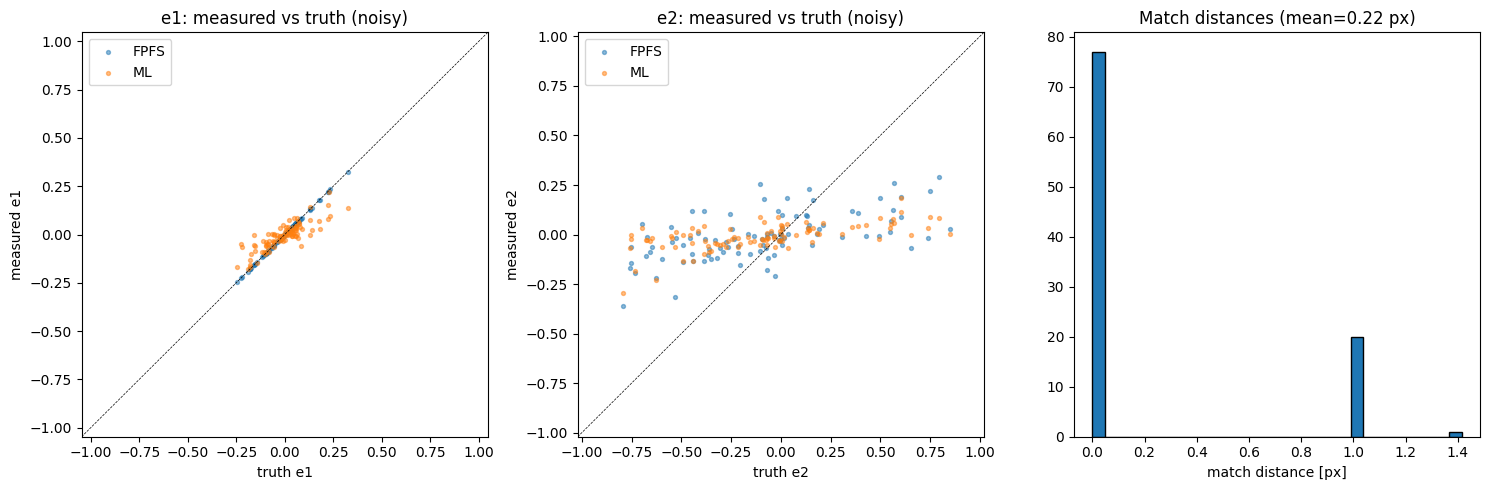

In [22]:
# ---- Phase 4c: Merge noisy catalog too ----
if 'det_cat' in dir() and 'ml_shapes' in dir():
    merged_path_noisy = merge_and_save_catalog(
        det_cat=det_cat,
        ml_shapes=ml_shapes,
        ml_R=ml_R,
        positions=positions,
        output_dir=OUTPUT_DIR,
        truth_cat=cat,
        fname="catalog_noisy",
        match_threshold=3.0,
    )
    
    # Quick FPFS vs ML vs truth scatter for e1 (noisy)
    df_noisy = pd.read_csv(f"{OUTPUT_DIR}/catalog_noisy.csv")
    matched = df_noisy[df_noisy['match_idx'] >= 0]
    
    if len(matched) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        ax = axes[0]
        ax.scatter(matched['fpfs_e1'], matched['fpfs_e1'], alpha=0.5, s=8, label='FPFS')
        ax.scatter(matched['fpfs_e1'], matched['ml_e1'], alpha=0.5, s=8, label='ML')
        all_vals_e1 = np.concatenate([matched['truth_e1'].values,
                                       matched['fpfs_e1'].values,
                                       matched['ml_e1'].values])
        lim = np.nanmax(np.abs(all_vals_e1)) * 1.2
        ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_xlabel('truth e1'); ax.set_ylabel('measured e1')
        ax.legend(); ax.set_title('e1: measured vs truth (noisy)')
        
        ax = axes[1]
        ax.scatter(matched['truth_e2'], matched['fpfs_e2'], alpha=0.5, s=8, label='FPFS')
        ax.scatter(matched['truth_e2'], matched['ml_e2'], alpha=0.5, s=8, label='ML')
        all_vals_e2 = np.concatenate([matched['truth_e2'].values,
                                       matched['fpfs_e2'].values,
                                       matched['ml_e2'].values])
        lim = np.nanmax(np.abs(all_vals_e2)) * 1.2
        ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_xlabel('truth e2'); ax.set_ylabel('measured e2')
        ax.legend(); ax.set_title('e2: measured vs truth (noisy)')
        
        ax = axes[2]
        ax.hist(matched['match_dist'], bins=30, edgecolor='black')
        ax.set_xlabel('match distance [px]')
        ax.set_title(f'Match distances (mean={matched["match_dist"].mean():.2f} px)')
        
        plt.tight_layout()
        plt.show()
else:
    print("Noisy data not available. Run Phase 1-3 noisy cells first.")

In [1]:
import numpy as np

temp_cat = np.load('/work/hdd/bfmo/wenyinli/measurement/xlens_sims/n01/g1_1/det_ml_fpfs_l5c32r01/catalog_0.npz')

In [12]:
np.array([temp_cat['x'], temp_cat['y']]).T

array([[ 64.,  64.],
       [143.,  64.],
       [224.,  64.],
       [225.,  64.],
       [304.,  64.],
       [384.,  64.],
       [464.,  64.],
       [544.,  64.],
       [625.,  64.],
       [704.,  64.],
       [784.,  64.],
       [ 64., 144.],
       [ 64., 224.],
       [ 64., 304.],
       [144., 144.],
       [224., 144.],
       [304., 144.],
       [144., 224.],
       [224., 224.],
       [304., 224.],
       [144., 304.],
       [224., 304.],
       [304., 304.],
       [384., 144.],
       [464., 144.],
       [384., 224.],
       [464., 224.],
       [384., 304.],
       [463., 304.],
       [464., 304.],
       [544., 144.],
       [624., 144.],
       [704., 144.],
       [544., 224.],
       [624., 224.],
       [704., 224.],
       [544., 304.],
       [624., 304.],
       [704., 304.],
       [784., 144.],
       [784., 224.],
       [784., 304.],
       [ 64., 384.],
       [ 64., 464.],
       [144., 384.],
       [224., 384.],
       [304., 384.],
       [144.,

## Calibration Test

In [3]:
# ---- Calibration Test: run get_det_calibration_biases on a small range ----
# This reads the NPZ catalogs produced by fpfsdet_MLshape_run.py / fpfsdet_shape_run.sh
# and runs the joint detection+selection+shape calibration.

import sys, os, time
sys.path.insert(0, '/projects/bdsp/wenyinli/codes/single_galaxies')
from src.blending.det_shape_calibration import get_det_calibration_biases
from src.anacal.cal_toolkit import format_number

# ---- Parameters ----
# Matches the output from fpfsdet_shape_run.sh:
#   --noise 0.1  →  folder="n01"
#   --fname det_ml_fpfs_l5c32r01
#   --range 0 20000
# NPZs are at: {output_root}/{folder}/{shear_comp}_{shear_mode}/{fname}/catalog_{index}.npz
OUTPUT_ROOT = "/work/hdd/bfmo/wenyinli/measurement/xlens_sims"
NOISE = 0.1
JOB_NAME = "det_ml_fpfs_l5c32r01"
BASE_DIR = os.path.join(OUTPUT_ROOT, format_number(NOISE))  # e.g. /.../xlens_sims/n01
IDX_RANGE = (0, 20000)   # small test — increase to (0, 1000) for real run
MAG_CUT = None        # set e.g. 25.0 for selection response
WORKERS = 64

print(f"=== Calibration Test ===")
print(f"  noise={NOISE}, job={JOB_NAME}")
print(f"  index_range={IDX_RANGE}")
print(f"  base_dir={BASE_DIR}")
print(f"  fname={JOB_NAME} (used as subdir name in NPZ path)")

t0 = time.time()

# ---- Run calibration (FPFS mode only for quick test) ----
result_fpfs = get_det_calibration_biases(
    noise_level=NOISE,
    job_name=JOB_NAME,
    fname=JOB_NAME,               # matches the subdir name in fpfsdet_MLshape_run
    index_range=IDX_RANGE,
    shape_mode="ml",            # switch to "both" for both FPFS & ML
    mag_cut=MAG_CUT,
    include_detection_response=True,
    bs_times=20,                  # fewer bootstrap for quick test
    is_twin=False,
    workers=WORKERS,
    base_dir=BASE_DIR,
    output_dir=f"./output/cali_test/{format_number(NOISE)}/{JOB_NAME}",
    log_csv="./output/cali_test/result.csv",
)

t1 = time.time()
print(f"\n{'='*50}")
print(f"Calibration result (ML, {IDX_RANGE}):")
m, c, m_err, c_err = result_fpfs
print(f"  m     = [{m[0]:.6f}, {m[1]:.6f}]")
print(f"  c     = [{c[0]:.6f}, {c[1]:.6f}]")
print(f"  m_err = [{m_err[0]:.6f}, {m_err[1]:.6f}]")
print(f"  c_err = [{c_err[0]:.6f}, {c_err[1]:.6f}]")
print(f"Total time: {t1 - t0:.1f}s")

=== Calibration Test ===
  noise=0.1, job=det_ml_fpfs_l5c32r01
  index_range=(0, 20000)
  base_dir=/work/hdd/bfmo/wenyinli/measurement/xlens_sims/n01
  fname=det_ml_fpfs_l5c32r01 (used as subdir name in NPZ path)
[det_calibration] noise=0.1 (n01), job=det_ml_fpfs_l5c32r01, fname=det_ml_fpfs_l5c32r01, batches=0..20000 (20000), shape_mode=ml
[det_calibration] base_dir=/work/hdd/bfmo/wenyinli/measurement/xlens_sims/n01

  Running calibration for shape_mode='ml'
[load] Dispatching 80000 NPZ loads with 64 workers...


Loading NPZ (ml): 100%|██████████| 80000/80000 [00:06<00:00, 12504.53it/s]


[load] Loaded 80000 files, 0 missing (0.0%), in 6.9s
[assemble] Per-condition N: [2043861, 2044134, 2044261, 2044278]
[detection_response] Per-condition: signal = w*e, response = w*R + dw/dg*e


[result] m = [-0.00391674 -0.00304191], c = [-6.45658883e-05  1.40376973e-04]
[result] m_err = [0.00670983 0.00602034], c_err = [0.00012768 0.00016981]

Calibration result (ML, (0, 20000)):
  m     = [-0.003917, -0.003042]
  c     = [-0.000065, 0.000140]
  m_err = [0.006710, 0.006020]
  c_err = [0.000128, 0.000170]
Total time: 32.1s
